In [22]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [24]:
(x_train,y_train),(x_test,y_test)=keras.datasets.cifar10.load_data()

In [25]:
print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)


Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [26]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

In [27]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [28]:
model = keras.Sequential([
    
    data_augmentation,  
    
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

In [29]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - accuracy: 0.3404 - loss: 1.8043 - val_accuracy: 0.5246 - val_loss: 1.3412
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.5083 - loss: 1.3878 - val_accuracy: 0.5330 - val_loss: 1.3532
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.5490 - loss: 1.2707 - val_accuracy: 0.6008 - val_loss: 1.1200
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.5787 - loss: 1.1915 - val_accuracy: 0.6062 - val_loss: 1.1239
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.5990 - loss: 1.1474 - val_accuracy: 0.6264 - val_loss: 1.0745
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.6134 - loss: 1.1024 - val_accuracy: 0.6470 - val_loss: 1.0203
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 43ms/step - accuracy: 0.6230 - loss: 1.0739 - val_accuracy: 0.6322 - val_loss: 1.0869
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.6339 - loss: 1.0406 - 

In [31]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6803 - loss: 0.9303
Test Accuracy: 0.6797999739646912


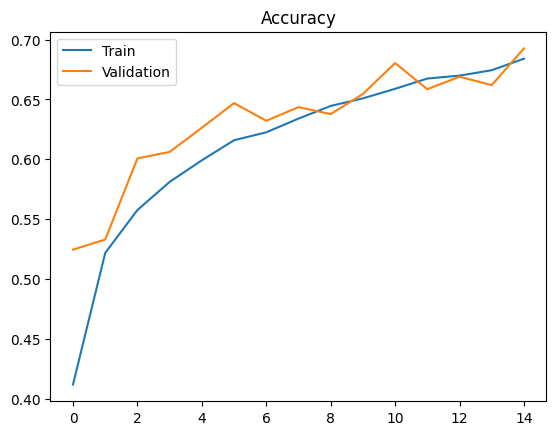

In [32]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train','Validation'])
plt.show()